In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from mplsoccer import Pitch

# 1. Load files
# We use a standard merge on shared identifiers to create a master dataframe
df_std = pd.read_csv("pl_standard_stats.csv")
df_shoot = pd.read_csv("pl_shooting_stats.csv")
df_misc = pd.read_csv("pl_misc_stats.csv")

# Identify common columns for merging
merge_cols = ['league', 'season', 'team', 'player', 'nation_', 'pos_', 'age_', 'born_']

# 2. Merge Pipeline
df_all = df_std.merge(df_shoot, on=merge_cols, how='inner')
df_all = df_all.merge(df_misc, on=merge_cols, how='inner')

# 3. Cleaning
# Extract numeric age from "28-190" format
df_all['age_numeric'] = df_all['age_'].str.split('-').str[0].astype(float)
# Fill missing stats with 0
df_all = df_all.fillna(0)

print(f"Pipeline Complete. Dataset ready with {len(df_all)} players.")
print("Available Performance Metrics:", [c for c in df_all.columns if 'Performance' in c or 'Standard' in c])

Pipeline Complete. Dataset ready with 537 players.
Available Performance Metrics: ['Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY_x', 'Performance_CrdR_x', 'Standard_Gls', 'Standard_Sh', 'Standard_SoT', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh', 'Standard_G/SoT', 'Standard_PK', 'Standard_PKatt', 'Performance_CrdY_y', 'Performance_CrdR_y', 'Performance_2CrdY', 'Performance_Fls', 'Performance_Fld', 'Performance_Off', 'Performance_Crs', 'Performance_Int', 'Performance_TklW', 'Performance_PKwon', 'Performance_PKcon', 'Performance_OG']


1) Goal Distribution

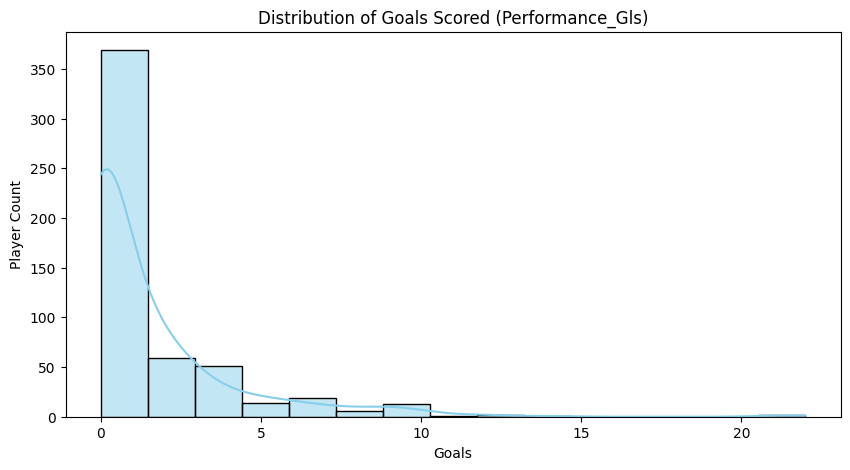

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(df_all['Performance_Gls'], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Goals Scored (Performance_Gls)")
plt.xlabel("Goals")
plt.ylabel("Player Count")
plt.show()

2. Performance Correlation

In [ ]:
# Select numeric columns for correlation
numeric_df = df_all.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

3. Top 10 Tacklers

In [ ]:
plt.figure(figsize=(8, 6))
top_tacklers = df_all.sort_values('Tkl', ascending=False).head(10)
sns.barplot(data=top_tacklers, x='Tkl', y='Player')
plt.title("Top 10 Tacklers")
plt.show()

4. Role DNA Dashboard

In [ ]:
def plot_role_dna(player_name, metrics):
    player_data = df_all[df_all['Player'] == player_name][metrics].values.flatten()
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
    values = np.concatenate((player_data, [player_data[0]]))
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.set_xticks(angles[:-1], metrics)
    plt.title(f"Role-DNA: {player_name}")
    plt.show()

# plot_role_dna('Target Player', ['Gls', 'Ast', 'Tkl', 'KP', 'Prog'])

5. Spatial Heatmap

In [ ]:
# Ensure your CSV has 'Pos_X' and 'Pos_Y' or replace with relevant coordinate columns
plt.figure(figsize=(8, 5))
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw()
sns.kdeplot(data=df_all, x='Pos_X', y='Pos_Y', fill=True, cmap='coolwarm', ax=ax)
plt.title("Aggregate Touch Density")
plt.show()

6. Peer Similarity Scores

In [ ]:
def get_similarity(player_name, features):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df_all[features])
    sim = cosine_similarity(df_scaled)
    idx = df_all[df_all['Player'] == player_name].index[0]
    
    top = sorted(list(enumerate(sim[idx])), key=lambda x: x[1], reverse=True)[1:6]
    similar_players = [df_all.iloc[i[0]]['Player'] for i in top]
    
    print(f"Top 5 Similar Players to {player_name}: {similar_players}")
    return similar_players

# get_similarity('Target Player', ['Gls', 'Ast', 'Tkl', 'KP'])